In [14]:
# how to handle time_factor!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# final output 0, 1, 2



import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from fmri_tools.utils.hrf import hrf_spm

file_in = "/home/daniel/Schreibtisch/p1_GE_EPI1_Run1_rivalry_Cond_clean.mat"
cond = loadmat(file_in)
onsets = cond["onsets"]
durations = cond["durations"]
#names = cond["names"]


names = np.array([i[0] for i in cond["names"][0]])

durations_left = cond["durations"][0][np.where(names=="left")[0][0]][0]
onsets_left = cond["onsets"][0][np.where(names=="left")[0][0]][0]
durations_right = cond["durations"][0][np.where(names=="right")[0][0]][0]
onsets_right = cond["onsets"][0][np.where(names=="right")[0][0]][0]

time_end = 270
time_factor = 1

time = np.linspace(0, 270, time_end * time_factor)



def bla(onsets, durations):
    y_cond = np.zeros_like(time)
    j = 0
    status = 0
    c = 0
    while j < len(onsets):
        if time[c] > onsets[j]:
            status = 1
        if status == 1 and time[c] > (onsets[j]+durations[j]):
            status = 0
            j += 1
        y_cond[c] = status
        c += 1
    return y_cond

In [15]:
shift = 0

y_cond_left = bla(onsets_left, durations_left)
y_cond_right = bla(onsets_right, durations_right)

y_cond_left = np.roll(y_cond_left, shift * time_factor)
y_cond_right = np.roll(y_cond_right, shift * time_factor)

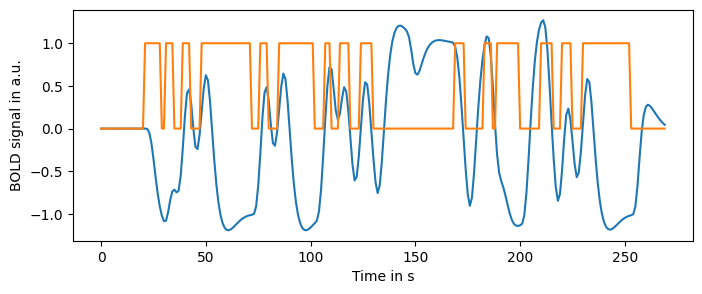

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.])

In [36]:
TR = 1.0  # repetition time in seconds
kernel = hrf_spm(TR/time_factor)


y_left = np.convolve(y_cond_left, kernel, mode="full")
y_left = y_left[:len(y_cond_left)]
y_right = np.convolve(y_cond_right, kernel, mode="full")
y_right = y_right[:len(y_cond_right)]


y_diff = y_left - y_right

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(y_diff)
ax.plot(y_cond_right)
ax.set_xlabel("Time in s")
ax.set_ylabel("BOLD signal in a.u.")
plt.show()


label = np.zeros_like(y_diff)
for i, y in enumerate(y_diff):
    if y > 0:
        label[i] = 1
    else:
        label[i] = -1
    if i < durations[0][0][0][0] or i >= time_end - durations[0][0][0][1]:
        label[i] = 0